In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from _architecture import Base

In [2]:
X = np.arange(0,22,1)
Y_true = (X>11.5).astype(np.int8)

# data
np.c_[X,Y_true]


array([[ 0,  0],
       [ 1,  0],
       [ 2,  0],
       [ 3,  0],
       [ 4,  0],
       [ 5,  0],
       [ 6,  0],
       [ 7,  0],
       [ 8,  0],
       [ 9,  0],
       [10,  0],
       [11,  0],
       [12,  1],
       [13,  1],
       [14,  1],
       [15,  1],
       [16,  1],
       [17,  1],
       [18,  1],
       [19,  1],
       [20,  1],
       [21,  1]])

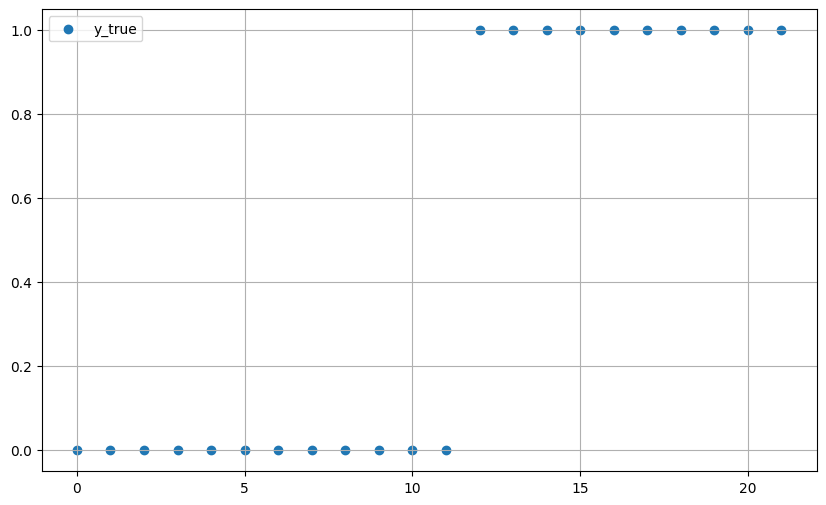

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y_true,label='y_true')
plt.legend()
plt.grid()
plt.show()

In [ ]:
class BinaryLogisticRegression(Base):

    def _sigmoid(self, z):
        
        return 1/ (1+ np.exp(-z))

    def _compute_loss(self,y_true, y_pred):
        # binary cross entropy
        eps = 1e-15
        return -np.mean(y_true* np.log(y_pred + eps ) + (1- y_true) * np.log(1- y_pred + eps))


    def fit(self,X, y ):

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        prev_loss = np.inf
        _wait = 0
        tol = 1e-17
        

        for itr in range(self.max_iterations):

            logits = np.dot(X,self.weights) + self.bias
            sig_y = self._sigmoid(logits)

            dw = np.sum(np.dot(X.T, (sig_y - y)))/n_samples
            db = np.sum(sig_y - y)/n_samples

            _loss = self._compute_loss(y,sig_y)

            self.weights -= self.lr*dw
            self.bias -=  self.lr*db

            if abs(prev_loss - _loss) < tol:
                _wait += 1
            else:
                _wait = 0 

            if _wait >= self.patience:
                if self._verbose: print(f"Converged at iteration {itr}")
                break

            if self._verbose and itr % 1000 == 0:
                print(f'[{itr}/{self.max_iterations}] loss : {_loss:.6f}')

            prev_loss = _loss
                
        self._is_fitted = True


    def predict_proba(self, X ):

        return self._sigmoid(X@self.weights + self.bias)
    

    def predict(self,X):
        
        _probs = self.predict_proba(X)
        return np.array([ 0 if i<0.5 else 1 for i in _probs])
    

    def score(self, y_true, y_pred):
        return self._compute_loss(y_true,y_pred)
    
    

In [5]:
lr_classifier = BinaryLogisticRegression(max_iterations=10**5,lr=1e-2,verbose= True)

X_=  X.reshape(-1,1)
lr_classifier.fit(X_,Y_true)

y_probs_ = lr_classifier.predict_proba(X_)
y_probs_

[0/100000] loss : 0.693147
[1000/100000] loss : 0.380499
[2000/100000] loss : 0.289984
[3000/100000] loss : 0.243715
[4000/100000] loss : 0.215181
[5000/100000] loss : 0.195517
[6000/100000] loss : 0.180960
[7000/100000] loss : 0.169636
[8000/100000] loss : 0.160504
[9000/100000] loss : 0.152937
[10000/100000] loss : 0.146530
[11000/100000] loss : 0.141011
[12000/100000] loss : 0.136191
[13000/100000] loss : 0.131930
[14000/100000] loss : 0.128127
[15000/100000] loss : 0.124704
[16000/100000] loss : 0.121600
[17000/100000] loss : 0.118766
[18000/100000] loss : 0.116166
[19000/100000] loss : 0.113767
[20000/100000] loss : 0.111545
[21000/100000] loss : 0.109478
[22000/100000] loss : 0.107547
[23000/100000] loss : 0.105739
[24000/100000] loss : 0.104041
[25000/100000] loss : 0.102440
[26000/100000] loss : 0.100929
[27000/100000] loss : 0.099498
[28000/100000] loss : 0.098141
[29000/100000] loss : 0.096851
[30000/100000] loss : 0.095622
[31000/100000] loss : 0.094450
[32000/100000] loss :

array([1.33540698e-06, 4.37650448e-06, 1.43429375e-05, 4.70044502e-05,
       1.54030792e-04, 5.04626778e-04, 1.65191065e-03, 5.39350281e-03,
       1.74616068e-02, 5.50381714e-02, 1.60286183e-01, 3.84833309e-01,
       6.72151972e-01, 8.70450920e-01, 9.56560250e-01, 9.86332680e-01,
       9.95789705e-01, 9.98711543e-01, 9.99606501e-01, 9.99879899e-01,
       9.99963350e-01, 9.99988817e-01])

In [6]:
y_pred_cls = lr_classifier.predict(X_)

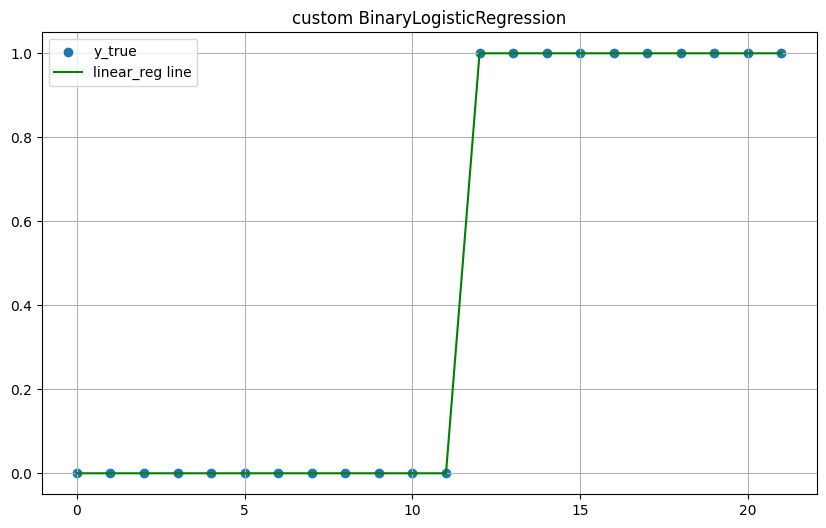

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y_true,label='y_true')
plt.plot(X,y_pred_cls,label='linear_reg line',color='green')
plt.legend()
plt.title('custom BinaryLogisticRegression')
plt.grid()
plt.show()

In [8]:
score_1  = lr_classifier.score(Y_true,np.array(y_pred_cls))
score_1

np.float64(-1.1102230246251561e-15)

In [9]:
## lets check our custom model performance against logistic regression

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_,Y_true)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_)
score_2 = lr_classifier.score(Y_true,y_pred)
score_2

np.float64(-1.1102230246251561e-15)

In [12]:
score_2 == score_1

np.True_

In [13]:
# Okay so we're accurate, but slower than real model.

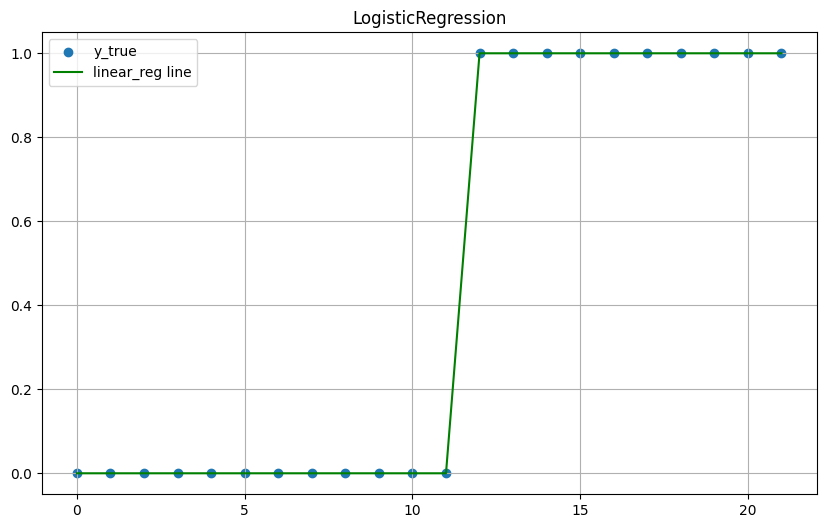

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y_true,label='y_true')
plt.plot(X,y_pred,label='linear_reg line',color='green')
plt.legend()
plt.title('LogisticRegression')
plt.grid()
plt.show()